## Neural Networks and Deep Learning Project

The goal of the project is to re-implement a famous Convolutionnal Architecture from scratch to showcase the resnet architecture against conventionnal convolution architecture.

### 0. Importing the libraries

In [1]:
from fastai.vision.all import *
import torch
import torch.nn as nn
from torch import tensor
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt
import csv
import os

In [2]:
configs = {18 : [2,2,2,2], 34 : [3,4,6,3]} #Sizes of the differents layers with different sizes

In [3]:
#For the classes, since i am working with Imagenette 160 I implemented a dictionnary to see the class that corresponds to the number (it won't work with another dataset)
id_to_english = {
    "n01440764": "Tench",
    "n02102040": "English springer",
    "n02979186": "Cassette player",
    "n03000684": "Chain saw",
    "n03028079": "Church",
    "n03394916": "French horn",
    "n03417042": "Garbage truck",
    "n03425413": "Gas pump",
    "n03445777": "Golf ball",
    "n03888257": "Parachute"
}
def get_name_from_id(class_id):
    """Return the classe's name if found in the dictionnary """
    return id_to_english.get(class_id, f"Unknown ({class_id})")

In [4]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3060


### 1.1 Loading the dataset
Before working on our model, we will start by loading the dataset from Imagenette using FASTAI for the loading and data-augmentation.

In [5]:
def get_data(url, presize, resize):
    path = untar_data(url)
    return DataBlock(
        blocks=(ImageBlock, CategoryBlock), get_items=get_image_files,
        splitter=GrandparentSplitter(valid_name='val'),
        get_y=parent_label, item_tfms=Resize(presize),
        batch_tfms=[*aug_transforms(min_scale=0.5, size=resize),
                    Normalize.from_stats(*imagenet_stats)],
    ).dataloaders(path, bs=128)

dls = get_data(URLs.IMAGENETTE_160, 160, 224) #128 avant

In [6]:
x, y = dls.one_batch()
print(x.shape)
print(f"Number of classes : {dls.c}")

torch.Size([128, 3, 224, 224])
Number of classes : 10


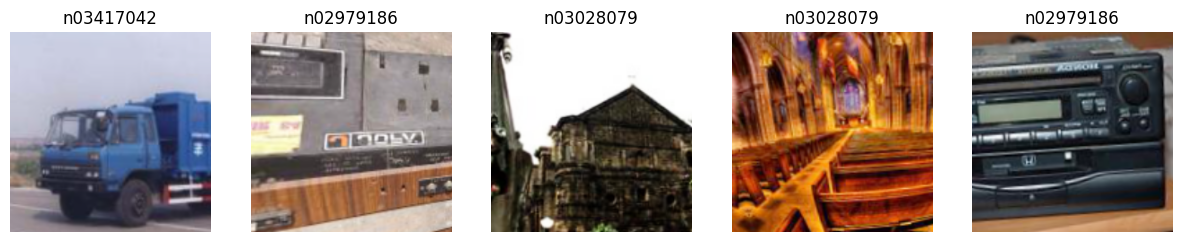

In [7]:
dls.show_batch(nrows=1, ncols=5)

The data is loaded, for now the batch size is 128, the image dimension is 128x128 and the color canal is RGB.

About the dataset itself, Imagenette 160 is a subset of Imagenette with only 10 different classes, the classe's ID format prevent confusion (when there is an homonym).

### 2.1 Building the architecture

According to Deep Residual Learning for Image Recognition, the resnet is made by alternating convolution and batch transformation. We will use the same structure than TP7.

In [8]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride, useBn = True):
      super().__init__()

      self.relu = nn.ReLU(inplace=True) #Will consume less space

      if not useBn :
        self.bn1 = nn.Identity()
        self.bn2 = nn.Identity()

      else :
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

      self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1)
      self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1)

      if stride == 2 or in_channels != out_channels :
        if not useBn : 
            self.shortcut = nn.Conv2d(in_channels, out_channels, 1, stride)
        else :
          self.shortcut = nn.Sequential(
              OrderedDict([
              ("conv_shortcut", nn.Conv2d(in_channels, out_channels, 1, stride)),
              ("batch_norm_shortcut", nn.BatchNorm2d(out_channels)),
          ]))
      else :
        self.shortcut = nn.Sequential() #When there is no parameters it won't change anything (no changes on x)


    def forward(self, x) :
      s = self.shortcut(x)

      x = self.conv1(x)
      x = self.bn1(x)

      x = self.relu(x)

      x = self.conv2(x)
      x = self.bn2(x)

      return self.relu(x + s)

In [9]:
class ResNet(nn.Module):
    def __init__(self, size, in_channels, useBn = True):
      super().__init__()

      if size not in configs :
        raise ValueError("This resnet's size is not valid")

      self.relu = nn.ReLU(inplace=True) #Will consume less space aussi

      self.conv1 = nn.Conv2d(in_channels, 64, 7, 2, padding=3)
      
      if not useBn :
        self.bn1 = nn.Identity()
      else : 
        self.bn1 = nn.BatchNorm2d(64)

      self.maxPool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

      self.in_channel = 64
      
      #Après le stem, les in_channels sont toujours 64

      #Maintenant on initialise les layers

      self.layer1 = self._make_layer(ResBlock, 64, configs[size][0], 1, useBn=useBn)
      self.layer2 = self._make_layer(ResBlock, 128, configs[size][1], 2, useBn=useBn)
      self.layer3 = self._make_layer(ResBlock, 256, configs[size][2], 2, useBn=useBn)
      self.layer4 = self._make_layer(ResBlock, 512, configs[size][3], 2, useBn=useBn)

      self.avgPool = nn.AvgPool2d(kernel_size = 7)
      self.fc = nn.Linear(512,10) #10 = nombre de classes d'imagenette


    def _make_layer(self, block, out_channel, n, stride = 1, useBn = True):
      #Je mets block pour pouvoir mettre un resblock ou un bottle neck

      layers = []

      for i in range(n) :
        if i == 0 :
          #Si c'est le premier layer du bloc, il faudra modifier la stride (ça peut arriver)
          layers.append(block(self.in_channel, out_channel, stride, useBn))
          self.in_channel = out_channel
          #Pour que si on a diviser par 2 avec la stride ça marche bien
        else :
          layers.append(block(self.in_channel, out_channel, 1, useBn))

      return nn.Sequential(*layers)


    def forward(self, x) :

        x = self.conv1(x)
        x = self.bn1(x) #Si on a désactivé la batch norm, ce sera comme faire une multiplication par 1
        x = self.relu(x)
        x = self.maxPool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgPool(x)
        #Flatten pour passer de batchx512x1x1 à batchx512
        x = self.fc(torch.flatten(x, 1,3))

        return x

### Basic Testing

In [10]:
tenseurTest = torch.randn((12, 3, 224, 224))
resnet = ResNet(34, 3)
output = resnet(tenseurTest)
print(output.shape)

torch.Size([12, 10])


In [11]:
def trainingModel(modele, dls, nbEpoch = 10, lr = 0.01, optimiser = "SGD",save_csv = None) :
  """ 
  


  """

  device = torch.device('cuda')
  modele = modele.to(device)

  if optimiser == "adam" :
    print("Using Adam")
    optimizer = torch.optim.Adam(modele.parameters(), lr = lr)
  else :
    optimizer = torch.optim.SGD(modele.parameters(), lr=lr, momentum = 0.9)
  #Sans momentum, l'accuracy oscille pas mal, du coup, plutôt que de manuellement tester les lr, je vais ajouter du momentum
  criterion = nn.CrossEntropyLoss()

  if save_csv:
        with open(save_csv, mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(['Epoch', 'Train_Loss', 'Val_Accuracy'])

  for i in range(nbEpoch) :
    modele.train()
    lossMoy = 0
    for x,y in dls.train :

       x = torch.tensor(x).to(device)
       y = torch.tensor(y).to(device)  #J'ai besoin de convertir pour pas avoir d'erreur avec le GPU

       optimizer.zero_grad()

       predictions = modele(x)

       loss = criterion(predictions, y)

       lossMoy += loss.item()

       loss.backward()

       optimizer.step()

  #Pour calculer l'accuracy à la fin de chaque epoch
    modele.eval()
    total_correct = 0
    with torch.no_grad():
      for x,y in dls.valid :
        x = torch.tensor(x).to(device)
        y = torch.tensor(y).to(device)  #J'ai besoin de convertir pour pas avoir d'erreur avec le GPU
        prediction_acc = modele(x)

        predictedClass = torch.argmax(prediction_acc, dim=1)

        correct = (predictedClass == y)

        total_correct += torch.sum(correct)

    train_loss = lossMoy/len(dls.train)
    valid_acc = (total_correct/len(dls.valid.dataset)).item()
    print(f"Epoch n°{i+1}, loss = {train_loss}, accuracy = {valid_acc}")

    if save_csv:
            with open(save_csv, mode='a', newline='') as file:
                writer = csv.writer(file)
                writer.writerow([i + 1, train_loss, valid_acc])


In [ ]:
monResnet = ResNet(34, 3, useBn=True)

trainingModel(monResnet, dls, 100, 0.001, optimiser="adam", save_csv="Adam_Resnet34_lr0.001.csv")

Using Adam


C:\Users\Maël\AppData\Local\Temp\ipykernel_2000\2858173774.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x).to(device)
C:\Users\Maël\AppData\Local\Temp\ipykernel_2000\2858173774.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y).to(device)  #J'ai besoin de convertir pour pas avoir d'erreur avec le GPU
C:\Users\Maël\AppData\Local\Temp\ipykernel_2000\2858173774.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x).to(device)
C:\Users\Maël\AppData\Local\Temp\ipykernel_2000\2858

Epoch n°1, loss = 1.8403550321108675, accuracy = 0.4155413806438446
Epoch n°2, loss = 1.4783532815436795, accuracy = 0.4058598577976227
Epoch n°3, loss = 1.2758613906494558, accuracy = 0.5732483863830566
Epoch n°4, loss = 1.1578673532564345, accuracy = 0.4868789613246918
Epoch n°5, loss = 1.0715829329947903, accuracy = 0.5442038178443909
Epoch n°6, loss = 1.006044815664422, accuracy = 0.5401273369789124
Epoch n°7, loss = 0.9246777312396324, accuracy = 0.547515869140625
Epoch n°8, loss = 0.9062555171039006, accuracy = 0.6030572652816772
Epoch n°9, loss = 0.8544798664850731, accuracy = 0.7317197322845459
Epoch n°10, loss = 0.8003766520382607, accuracy = 0.6338853240013123
Epoch n°11, loss = 0.7725655060924895, accuracy = 0.706242024898529
Epoch n°12, loss = 0.728399346544318, accuracy = 0.7429298758506775
Epoch n°13, loss = 0.7063506217035529, accuracy = 0.6746496558189392
Epoch n°14, loss = 0.6803615260614108, accuracy = 0.7187260985374451
Epoch n°15, loss = 0.6731528896991521, accuracy

# Experimentation 
(I will write my result for different parameters) 

### <u>Resnet-18, 100 Epochs, lr = 0.01, Batch normalization = True/False</u>

(The resnet-18, with batch normalisation will be my baseline)

| Epoch | Baseline Loss | Baseline Acc | Loss (No batch Normalisation) | Acc (No Batch Normalisation) |
| :---: | :--------: | :-----------: | :--------: | :-------: |
| **1**     | 1.8016    | 0.4343       | 2.2747      | 0.1880     |
| **5**     | 0.9636    | 0.6596       | 1.8514      | 0.3890     |
| **25**    | 0.3626    | 0.8079       | 0.8772      | 0.7325     |
| **50**    | 0.2012    | 0.8408       | 0.4984      | 0.8229     |
| **98**    | 0.0599    | 0.8540       | 0.2187      | 0.8469     |
| **99**    | 0.0594    | 0.8683       | 0.2044      | 0.8400     |
| **100**   | 0.0844    | 0.8206       | 0.1896      | 0.8270     |



Without batch normalisation, the loss and accuracy at the start are worst but the final accuracies are similar. The final loss is higher, it means that the model is less confident in its predictions.
Overall, without batch normalisation our model seems to converge slower.

### <u>Now, with a different learning rate (lr = 0.1)</u>
(With a greater learning rate, i want to check if the batch normalisation will help stabilizing my model)

### <u>Resnet-18, 100 Epochs, lr = 0.1, Batch normalization = True</u> 

| Epoch | Loss (No batch Normalisation) | Acc (No Batch Normalisation) | Loss (With Batch Normalisation) | Acc (With Batch Normalisation) |
| :---: | :---: | :---: | :---: | :---: |
| **1** | 2.2889 | 0.0993 | 2.8280 | 0.2280 |
| **5** | 2.0140 | 0.3253 | 1.4821 | 0.5278 |
| **25** | 0.8745 | 0.7258 | 0.6015 | 0.7320 |
| **50** | 0.5178 | 0.7885 | 0.3202 | 0.8270 |
| **98** | 0.2186 | 0.8468 | 0.0981 | 0.8499 |
| **99** | 0.2044 | 0.8399 | 0.0916 | 0.8436 |
| **100** | 0.1896 | 0.8270 | 0.0924 | 0.8504 |

We can see that Batch Normalization allows us to use bigger learning rate without diverging.

## Changing Optmizer
For the pervious experimentation, I used SGD optimiser with a momentum of 0.9, now i will use **Adam** since it uses adaptive learning rates for each parameters.

### <u>Resnet-18, 100 Epochs, lr = 0.1/0.01 </u> 
Here, the learning rate correspond to the 

| Epoch | Loss (lr = 0.1) | Acc (lr = 0.1) | Loss (With Batch Normalisation) | Acc (With Batch Normalisation) |
| :---: | :---: | :---: | :---: | :---: |
| **1** | 3.2887 | 0.1903 | 2.8280 | 0.2280 |
| **5** | 1.9388 | 0.3516 | 1.4821 | 0.5278 |
| **25** | 0.9689 | 0.4958 | 0.6015 | 0.7320 |
| **50** | 0.5540 | 0.7883 | 0.3202 | 0.8270 |
| **98** | 0.2187 | 0.8469 | 0.0981 | 0.8499 |
| **99** | 0.2044 | 0.8400 | 0.0916 | 0.8436 |
| **100** | 0.1896 | 0.8270 | 0.0924 | 0.8504 |



### Another Test

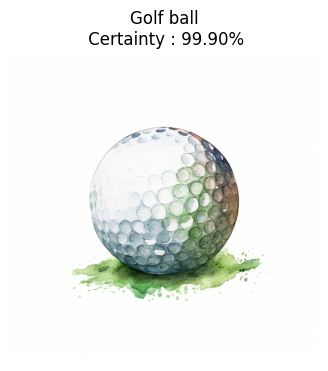

In [13]:
#I took different picture on google image and tried to apply it to my model.

img_pil = Image.open("Test_Golf.png").convert('RGB')

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

img_tensor = transform(img_pil).unsqueeze(0).to(torch.device('cuda'))

monResnet.eval()
with torch.no_grad():
    logits = monResnet(img_tensor)
    probs = torch.nn.functional.softmax(logits, dim=1)

score_max, index_max = torch.max(probs, 1)
confiance = score_max.item() * 100

raw_id = dls.vocab[index_max.item()]
real_name = get_name_from_id(raw_id)

plt.figure(figsize=(4, 4))
plt.imshow(img_pil)
plt.axis('off')
plt.title(f"{real_name}\n Certainty : {confiance:.2f}%")
plt.show()